### Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

### Import Data

In [3]:
ph_restos = pd.read_csv("ph_restos_2025.csv", keep_default_na=False)

# Lowercase store names & food type
ph_restos["CompleteStoreName"] = ph_restos["CompleteStoreName"].apply(str.lower)
ph_restos["FoodType"] = ph_restos["FoodType"].apply(str.lower)

# Drop row if 0 reviewers
ph_restos = ph_restos[ph_restos["Reviewers"] != 0]

### One Hot Encoding of Categorical Data (Restaurant Type) & Replacement of City w/ its Respective Population Density

In [4]:
types = ph_restos["FoodType"].tolist()
print(len(types))

enc = OneHotEncoder(handle_unknown='ignore')
enc.fit([[i] for i in types])
print(enc.categories_)
encoded_types = enc.transform([[i] for i in types]).toarray().tolist()

cities = ph_restos["City"].tolist()
pop_densities = []

city_pop_densities = {
    'cebu city': 3061, # highly urbanized
    'dagupan pangasinan': 4682,
    'davao city davao del sur': 727, # highly urbanized
    'koronadal south cotabato': 705, 
    'lapu-lapu city cebu': 8565, # highly urbanized
    'makati city': 25189, # highly urbanized
    'malolos bulacan': 3884,
    'mandaluyong city': 45830, # highly urbanized
    'manila': 73920, # highly urbanized
    'marikina': 21192, # highly urbanized
    'muntinlupa city': 13672, # highly urbanized
    'ormoc leyte': 376,
    'pasay city': 31543, # highly urbanized
    'pasig city': 16574, # highly urbanized
    'quezon city': 17239, # highly urbanized
    'san juan': 21235, # highly urbanized
    'taguig city': 19613, # highly urbanized
    'valencia bukidnon': 369, 
}

for entry in cities:
    pop_densities.append(city_pop_densities[entry])

city_and_resto_type = []

for i, row in enumerate(encoded_types):
    combined = [pop_densities[i]] + row
    city_and_resto_type.append(combined)

for row in city_and_resto_type:
    print(row)

print(len(city_and_resto_type[1]))

9372
[array(['', 'alcoholic drinks', 'american', 'asian', 'bbq', 'beverages',
       'biryani', 'bread', 'bulalo', 'burgers', 'cakes', 'chicken',
       'chicken wings', 'chinese', 'coffee', 'corndogs', 'curry',
       'desserts', 'dim sum ', 'donut', 'dumpling', 'fast food',
       'filipino', 'fish', 'fried chicken', 'fries', 'fruit shake',
       'halo-halo', 'healthy', 'ice cream', 'indian', 'italian',
       'japanese', 'kare kare', 'korean', 'lechon', 'liempo', 'lomi',
       'middle eastern', 'milk tea', 'noodles', 'pancakes & waffles',
       'pancit', 'pares', 'pasta', 'pizza', 'porridge', 'ramen',
       'rice bowl', 'rice dishes', 'rice noodles', 'salads', 'sandwiches',
       'seafood', 'shawarma', 'silog', 'sinigang', 'siomai', 'sisig',
       'snacks', 'soups', 'sushi', 'takoyaki', 'thai', 'ulam', 'western',
       'wraps'], dtype=object)]
[73920, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0

### Average Ratings per Restaurant

In [11]:
ratings = ph_restos["AverageRating"].to_list()
print(len(ratings))
print('ratings', ph_restos["AverageRating"].var())

9372
ratings 0.05316856785627311


### Model Training (Linear Regression)

0.024155372870178993
{'japanese': 0, 'beverages': 1, 'asian': 2, 'fast food': 3, 'chicken': 4, 'filipino': 5, 'ice cream': 6, 'pizza': 7, 'burgers': 8, 'coffee': 9, 'shawarma': 10, 'milk tea': 11, 'takoyaki': 12, 'desserts': 13, 'lechon': 14, 'donut': 15, 'sisig': 16, 'american': 17, 'sandwiches': 18, 'sushi': 19, 'fried chicken': 20, 'fish': 21, '': 22, 'fruit shake': 23, 'bread': 24, 'halo-halo': 25, 'indian': 26, 'chinese': 27, 'cakes': 28, 'thai': 29, 'pasta': 30, 'chicken wings': 31, 'silog': 32, 'korean': 33, 'fries': 34, 'rice dishes': 35, 'siomai': 36, 'salads': 37, 'lomi': 38, 'ramen': 39, 'pancakes & waffles': 40, 'rice bowl': 41, 'soups': 42, 'healthy': 43, 'biryani': 44, 'italian': 45, 'curry': 46, 'western': 47, 'noodles': 48, 'snacks': 49, 'ulam': 50, 'liempo': 51, 'bbq': 52, 'bulalo': 53, 'rice noodles': 54, 'middle eastern': 55, 'seafood': 56, 'pancit': 57, 'wraps': 58, 'porridge': 59, 'dim sum ': 60, 'dumpling': 61, 'pares': 62, 'sinigang': 63, 'corndogs': 64, 'kare ka

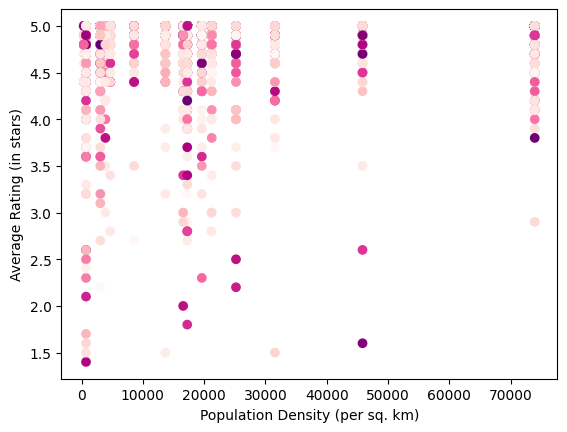

In [14]:
reg = LinearRegression().fit(city_and_resto_type, ratings)
print(reg.score(city_and_resto_type, ratings))

unique_types = dict()
type_counter = dict()
i = 0

for type in ph_restos["FoodType"].unique():
    if type not in unique_types.keys():
        unique_types[type] = i
        i += 1

for type in ph_restos["FoodType"]:
    if type not in type_counter.keys():
        type_counter[type] = 1
    else:
        type_counter[type] += 1

print(unique_types)
# print(type_counter)
# print('min', min(type_counter.values()))

filtered_types = dict()
filtered = []

for key, value in type_counter.items():
    if value > 25:
        filtered_types[key] = value
    else:
        filtered.append(key)

# print('filtered', filtered_types)
# print(len(filtered_types))
# print(filtered)

num_types = []
for entry in ph_restos['FoodType'].tolist():
    if entry != 'FoodType':
        num_types.append(unique_types[entry])

# print(num_types)

plt.scatter(pop_densities, ratings, c=num_types, cmap='RdPu')
plt.xlabel("Population Density (per sq. km)")
plt.ylabel("Average Rating (in stars)")
plt.show()

### Model Training (Decision Tree Regression)

In [7]:
# Splitting the dataset (80-20)
X_train, X_test, Y_train, Y_test = train_test_split(city_and_resto_type, ratings, test_size=0.2, random_state=24)

regressor = DecisionTreeRegressor(random_state=42)
regressor.fit(X_train, Y_train)

y_pred = regressor.predict(X_test)
print('predicted values of y:', y_pred)
print('expected values of y:', Y_test)
mae = mean_absolute_error(Y_test, y_pred)
print('Initial Mean Absolute Error (MAE):', mae)
print('Score (R^2):', regressor.score(city_and_resto_type, ratings))

path = regressor.cost_complexity_pruning_path(city_and_resto_type, ratings)
ccp_alphas = path.ccp_alphas
# print(len(ccp_alphas))
# print(ccp_alphas)

max = 0
best_ccp = 0
for ccp in ccp_alphas:
    if ccp >= 0:
        model = DecisionTreeRegressor(random_state=42, ccp_alpha=ccp)
        model.fit(X_train, Y_train)
        score = model.score(city_and_resto_type, ratings)

        if score > max:
            max = score
            best_ccp = ccp

print('Best ccp_alpha value:', best_ccp)

best_model = DecisionTreeRegressor(random_state=42, ccp_alpha=best_ccp)
best_model.fit(X_train, Y_train)
y_pred = regressor.predict(X_test)
mae = mean_absolute_error(Y_test, y_pred)
print('Best MAE:', mae)
print('Score (R^2):', best_model.score(city_and_resto_type, ratings))


predicted values of y: [4.83333333 4.83529412 4.89166667 ... 4.94       4.93205128 4.99      ]
expected values of y: [5.0, 4.9, 4.9, 5.0, 5.0, 4.9, 4.7, 4.8, 4.9, 5.0, 5.0, 5.0, 4.9, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 4.9, 4.9, 4.9, 5.0, 5.0, 4.9, 5.0, 5.0, 4.9, 5.0, 5.0, 5.0, 4.8, 5.0, 5.0, 4.8, 5.0, 5.0, 5.0, 4.9, 4.9, 5.0, 5.0, 5.0, 5.0, 5.0, 4.7, 5.0, 5.0, 4.9, 4.8, 5.0, 5.0, 5.0, 4.9, 4.8, 5.0, 4.9, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 4.9, 5.0, 4.8, 5.0, 5.0, 5.0, 4.8, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 4.3, 5.0, 5.0, 4.9, 5.0, 4.9, 5.0, 4.9, 4.9, 5.0, 4.9, 5.0, 4.9, 4.9, 5.0, 4.9, 4.9, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 4.9, 4.9, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 4.9, 5.0, 2.8, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 4.9, 4.9, 4.7, 5.0, 5.0, 5.0, 5.0, 4.8, 5.0, 4.9, 5.0, 2.9, 4.6, 4.7, 5.0, 5.0, 4.8, 5.0, 4.8, 4.9, 5.0, 4.9, 5.0, 4.9, 5.0, 5.0, 5.0, 5.0, 5.0, 4.9, 4.9, 4.8, 5.0, 3.8, 5.0, 4.9, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 4.9, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.

### Model Training (Random Forest Regression)

In [8]:
# Splitting the dataset (80-20)
X_train, X_test, Y_train, Y_test = train_test_split(city_and_resto_type, ratings, test_size=0.2, random_state=42)

regressor = RandomForestRegressor(random_state=42)
regressor.fit(X_train, Y_train)

y_pred = regressor.predict(X_test)
print('predicted values of y:', y_pred)
print('expected values of y', Y_test)
mae = mean_absolute_error(Y_test, y_pred)
print('Mean Absolute Error (MAE):', mae)
print('Score (R^2):', regressor.score(city_and_resto_type, ratings))


predicted values of y: [4.96749391 4.95452776 4.89967244 ... 4.97025536 4.52826582 4.96464167]
expected values of y [5.0, 5.0, 5.0, 4.9, 5.0, 5.0, 5.0, 5.0, 3.7, 5.0, 4.9, 5.0, 5.0, 5.0, 5.0, 4.8, 4.9, 4.9, 5.0, 5.0, 4.9, 5.0, 5.0, 4.9, 5.0, 5.0, 4.9, 5.0, 5.0, 4.9, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 4.9, 4.8, 5.0, 5.0, 4.9, 5.0, 5.0, 5.0, 5.0, 5.0, 4.9, 5.0, 5.0, 5.0, 5.0, 4.8, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 4.9, 4.6, 5.0, 4.9, 5.0, 5.0, 5.0, 4.9, 5.0, 5.0, 4.7, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 3.0, 4.8, 4.9, 4.9, 4.9, 4.7, 4.9, 5.0, 4.8, 4.8, 4.9, 4.9, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 4.8, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 4.9, 5.0, 5.0, 5.0, 5.0, 4.7, 5.0, 4.8, 5.0, 5.0, 4.8, 5.0, 5.0, 5.0, 5.0, 3.0, 5.0, 5.0, 4.4, 5.0, 4.9, 5.0, 5.0, 3.5, 4.8, 4.9, 4.9, 5.0, 5.0, 4.9, 5.0, 5.0, 5.0, 4.9, 5.0, 5.0, 4.9, 4.8, 5.0, 4.9, 5.0, 4.8, 4.9, 5.0, 4.9, 5.0, 4.9, 5.0, 4.9, 4.7, 5.0, 5.0, 5.0, 5.0, 4.8, 5.0, 5.0, 4.7, 4.8, 5.0, 5.0, 5.0, 4.9, 5.0, 4.9, 4.6, 4.9, 4.9, 4.8, 4.9

In [9]:
# Sample Predictions
list = [0.0 for i in range(55)]
list[0] = 17239
list[20] = 1
print(X_test[100])
print(len(X_test[100]))
print(regressor.predict([X_test[100]]))

[25189, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
68
[4.90851971]
